In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('supermarket_data.csv')
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09/12/11 12:50,4.95,12680.0,France


In [3]:
df.head(60)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/10 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/10 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01/12/10 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01/12/10 08:28,1.85,17850.0,United Kingdom
9,536368,22960,JAM MAKING SET WITH JARS,6,01/12/10 08:34,4.25,13047.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [6]:
# Check whether missing vaulues of CUstomer ID correlated to Description
# If yes, then we just drop all missing values of Customer ID
print((df['Customer ID'].isna() & df['Description'].isna()).sum())

1454


In [7]:
df.dropna(subset=['Customer ID'], inplace=True)
print('Successfully drop all missing values')

Successfully drop all missing values


In [8]:
# Handling duplicates value
df.drop_duplicates(inplace=True)
print("Successfully drop all duplicate values")

Successfully drop all duplicate values


In [9]:
print("Table's shape currently:", df.shape)
print(df.columns.tolist())

Table's shape currently: (401605, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401605 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      401605 non-null  object 
 1   StockCode    401605 non-null  object 
 2   Description  401605 non-null  object 
 3   Quantity     401605 non-null  int64  
 4   InvoiceDate  401605 non-null  object 
 5   Price        401605 non-null  float64
 6   Customer ID  401605 non-null  float64
 7   Country      401605 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [11]:
# Standardize invalid column data type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int).astype('object')
df.info()

C:\Users\rober\AppData\Local\Temp\ipykernel_6764\542418375.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


<class 'pandas.core.frame.DataFrame'>
Index: 401605 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      401605 non-null  object        
 1   StockCode    401605 non-null  object        
 2   Description  401605 non-null  object        
 3   Quantity     401605 non-null  int64         
 4   InvoiceDate  401605 non-null  datetime64[ns]
 5   Price        401605 non-null  float64       
 6   Customer ID  401605 non-null  object        
 7   Country      401605 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.6+ MB


In [12]:
# Building RFM (Recency, Frequency, Monetary) Framework

referenced_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (referenced_date - x.max()).days, #Recency
    'Invoice': 'count', #Frequency
    'Price': lambda x: (x * df.loc[x.index, 'Quantity']).sum() #Monetary
}).rename(columns={
    'InvoiceDate':'Recency',
    'Invoice':'Frequency',
    'Price':'Monetary'
})

print(rfm)

             Recency  Frequency  Monetary
Customer ID                              
12346            326          2      0.00
12347             40        182   4310.00
12348             76         31   1797.24
12349             19         73   1757.55
12350            311         17    334.40
...              ...        ...       ...
18280            160         10    180.60
18281              4          7     80.82
18282             93         13    176.60
18283             10        721   2045.53
18287              0         70   1837.28

[4372 rows x 3 columns]


In [13]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# Applying k-means model for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaler = scaler.fit_transform(rfm)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, max_iter=500, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaler)
print(rfm)

             Recency  Frequency  Monetary  cluster
Customer ID                                       
12346            326          2      0.00        0
12347             40        182   4310.00        0
12348             76         31   1797.24        0
12349             19         73   1757.55        0
12350            311         17    334.40        0
...              ...        ...       ...      ...
18280            160         10    180.60        0
18281              4          7     80.82        0
18282             93         13    176.60        0
18283             10        721   2045.53        0
18287              0         70   1837.28        0

[4372 rows x 4 columns]


In [15]:
rfm['cluster'].value_counts()

cluster
0    4361
2       6
1       5
Name: count, dtype: int64


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


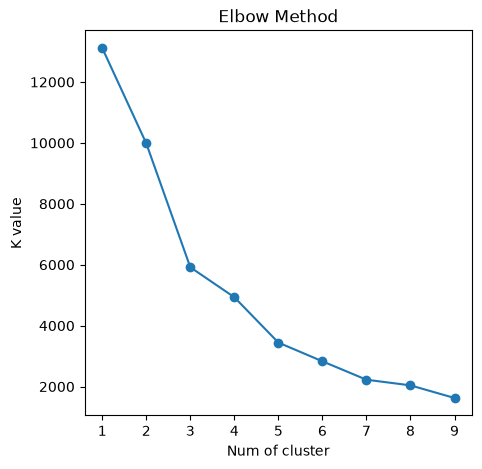

In [17]:
%pip install matplotlib
#plot inertia by elbow method
import matplotlib.pyplot as plt

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters = k, random_state = 1)
    kmeans.fit(rfm_scaler)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(5,5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method')
plt.ylabel('K value')
plt.xlabel('Num of cluster')
plt.show()

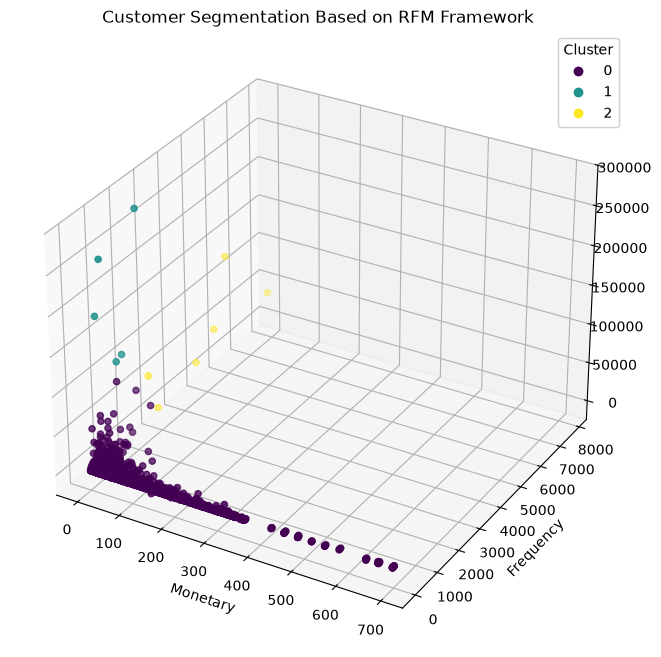

Silhouette score: 0.48830635772300157


In [21]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], c=rfm['cluster'])

ax.set_title('Customer Segmentation Based on RFM Framework')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_xlabel('Monetary')
legend = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend)
plt.show()

# Calculate silhouette score
from sklearn.metrics import silhouette_score
s_score = silhouette_score(rfm_scaler, kmeans.labels_)
print("Silhouette score:", s_score)